<a href="https://colab.research.google.com/github/asqarbek21/week6/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
**Exercises summary:**  
- **Part A (50%):** 3-feature pass/fail data generation, pairwise visualization, and NumPy decision tree (using the class from Section 3) with pairwise decision boundaries and prediction.  
- **Part B (30%):** Same 3-feature problem with scikit-learn: train, plot boundaries, and predict.  
- **Part C (20%):** Iris dataset: load, train decision tree, visualize (e.g. 2D boundary), report accuracy.

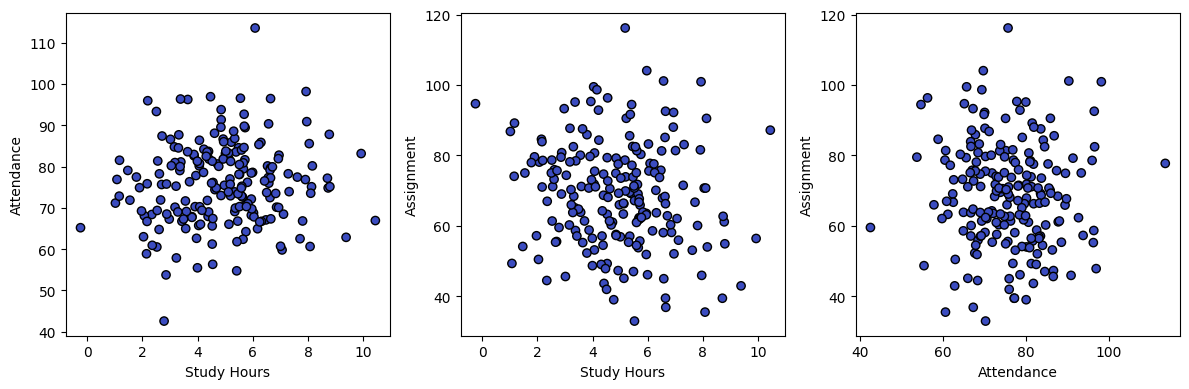

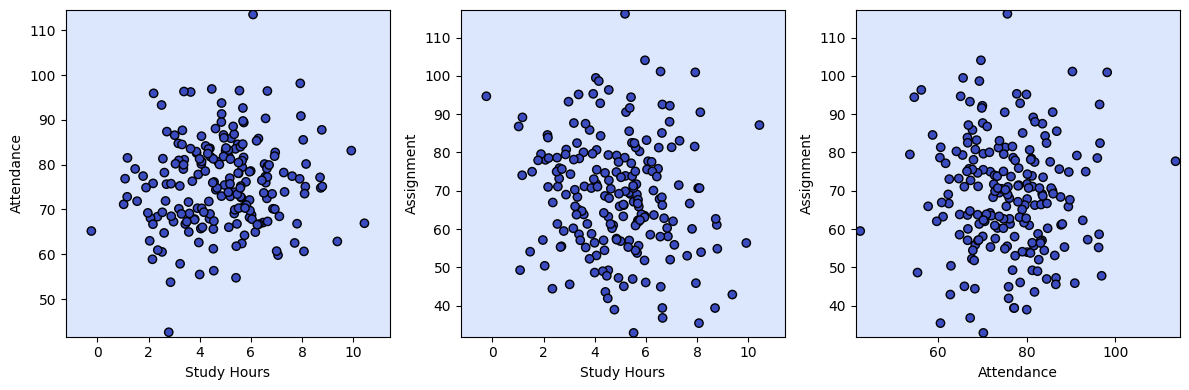

Prediction: Fail


In [1]:
 # part A. 3-feature pass/fail data generation, pairwise visualization, and NumPy decision tree with pairwise decision boundaries and prediction.



import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def gini_impurity(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

class DecisionTreeClassifier:

    def __init__(self, criterion='gini', max_depth=5):
        self.criterion = criterion
        self.max_depth = max_depth
        self.impurity_fn = gini_impurity if criterion == 'gini' else entropy
        self.tree = None

    def _find_best_split(self, X, y):
        n_samples, n_features = X.shape
        if n_samples <= 1:
            return None, None

        impurity_before = self.impurity_fn(y)
        best_gain = -1
        best_feature = None
        best_threshold = None

        for feat in range(n_features):

            values = np.unique(X[:, feat])

            for i in range(len(values) - 1):

                thresh = (values[i] + values[i + 1]) / 2

                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask

                y_left = y[left_mask]
                y_right = y[right_mask]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                n_left = len(y_left)
                n_right = len(y_right)

                impurity_left = self.impurity_fn(y_left)
                impurity_right = self.impurity_fn(y_right)

                impurity_after = (
                    n_left * impurity_left +
                    n_right * impurity_right
                ) / n_samples

                gain = impurity_before - impurity_after

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat
                    best_threshold = thresh

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):

        if (
            depth >= self.max_depth or
            len(np.unique(y)) == 1 or
            len(y) < 2
        ):
            majority_class = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': majority_class}

        feat, thresh = self._find_best_split(X, y)

        if feat is None:
            majority_class = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': majority_class}

        left_mask = X[:, feat] <= thresh
        right_mask = ~left_mask

        left_tree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': feat,
            'threshold': thresh,
            'left': left_tree,
            'right': right_tree
        }

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.tree = self._build_tree(X, y, 0)
        return self

    def _predict_one(self, x, node):

        if node['leaf']:
            return node['value']

        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])

        return self._predict_one(x, node['right'])

    def predict(self, X):

        X = np.asarray(X)

        return np.array([
            self._predict_one(x, self.tree)
            for x in X
        ])


np.random.seed(42)

n_samples = 200

study_hours = np.random.normal(5, 2, n_samples)
attendance = np.random.normal(75, 10, n_samples)
assignment = np.random.normal(70, 15, n_samples)

X = np.column_stack((study_hours, attendance, assignment))

y = ((study_hours*0.4 + attendance*0.3 + assignment*0.3) > 65).astype(int)

feature_names = ["Study Hours", "Attendance", "Assignment"]

pairs = [(0,1),(0,2),(1,2)]

plt.figure(figsize=(12,4))

for i,(f1,f2) in enumerate(pairs):

    plt.subplot(1,3,i+1)

    plt.scatter(
        X[:,f1],
        X[:,f2],
        c=y,
        cmap='coolwarm',
        edgecolors='k'
    )

    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])

plt.tight_layout()
plt.show()

tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4
)

tree.fit(X,y)


def plot_boundary(model,X,y,f1,f2):

    x_min, x_max = X[:,f1].min()-1, X[:,f1].max()+1
    y_min, y_max = X[:,f2].min()-1, X[:,f2].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,100),
        np.linspace(y_min,y_max,100)
    )

    grid = np.zeros((xx.ravel().shape[0],3))

    grid[:,f1] = xx.ravel()
    grid[:,f2] = yy.ravel()

    for i in range(3):
        if i not in [f1,f2]:
            grid[:,i] = X[:,i].mean()

    Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='coolwarm'
    )

    plt.scatter(
        X[:,f1],
        X[:,f2],
        c=y,
        cmap='coolwarm',
        edgecolors='k'
    )


plt.figure(figsize=(12,4))

for i,(f1,f2) in enumerate(pairs):

    plt.subplot(1,3,i+1)

    plot_boundary(tree,X,y,f1,f2)

    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])

plt.tight_layout()
plt.show()


student = np.array([[6,80,75]])

prediction = tree.predict(student)

print("Prediction:", "Pass" if prediction[0]==1 else "Fail")

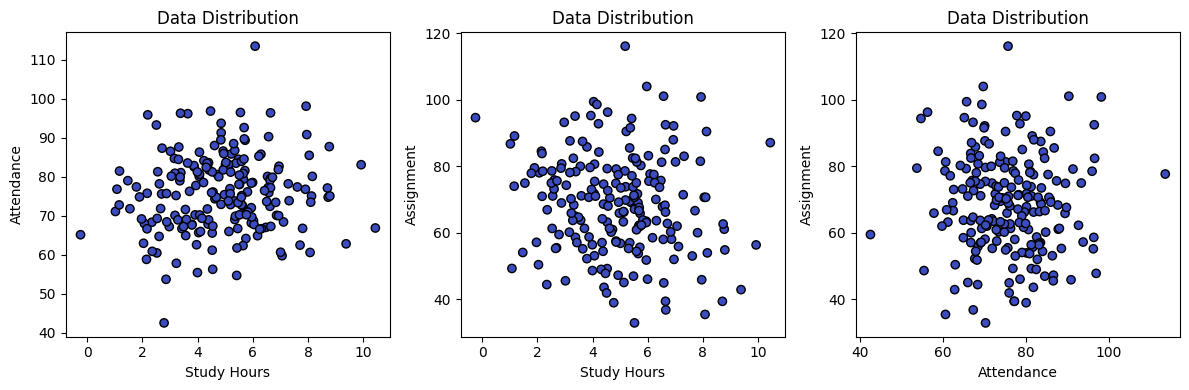

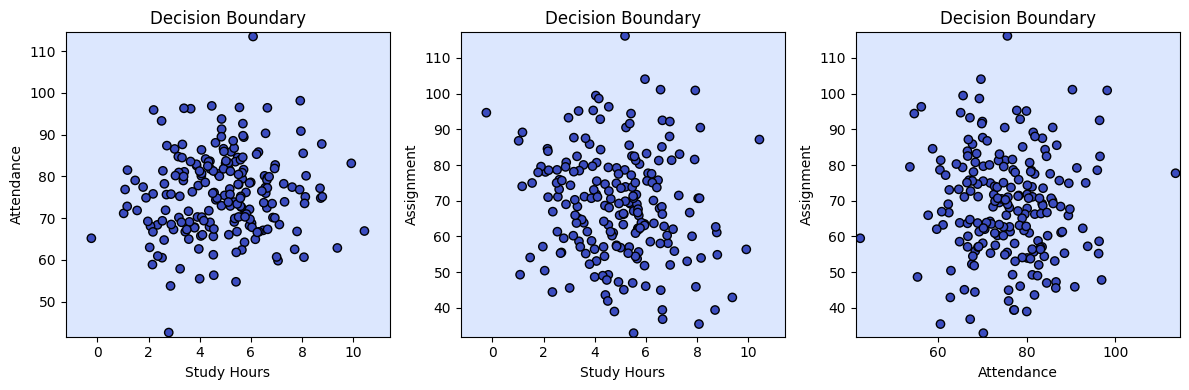

Prediction: Fail


In [2]:
# part B. Same 3-feature problem with scikit-learn: train, plot boundaries, and predict.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


np.random.seed(42)

n_samples = 200

study_hours = np.random.normal(5, 2, n_samples)
attendance = np.random.normal(75, 10, n_samples)
assignment = np.random.normal(70, 15, n_samples)

X = np.column_stack((study_hours, attendance, assignment))

y = ((study_hours*0.4 + attendance*0.3 + assignment*0.3) > 65).astype(int)

feature_names = ["Study Hours", "Attendance", "Assignment"]
pairs = [(0,1),(0,2),(1,2)]


plt.figure(figsize=(12,4))

for i,(f1,f2) in enumerate(pairs):

    plt.subplot(1,3,i+1)

    plt.scatter(
        X[:,f1],
        X[:,f2],
        c=y,
        cmap='coolwarm',
        edgecolors='k'
    )

    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])
    plt.title("Data Distribution")

plt.tight_layout()
plt.show()


model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X,y)


def plot_boundary(model,X,y,f1,f2):

    x_min, x_max = X[:,f1].min()-1, X[:,f1].max()+1
    y_min, y_max = X[:,f2].min()-1, X[:,f2].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,100),
        np.linspace(y_min,y_max,100)
    )

    grid = np.zeros((xx.ravel().shape[0],3))

    grid[:,f1] = xx.ravel()
    grid[:,f2] = yy.ravel()


    for i in range(3):
        if i not in [f1,f2]:
            grid[:,i] = X[:,i].mean()

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='coolwarm'
    )

    plt.scatter(
        X[:,f1],
        X[:,f2],
        c=y,
        cmap='coolwarm',
        edgecolors='k'
    )


plt.figure(figsize=(12,4))

for i,(f1,f2) in enumerate(pairs):

    plt.subplot(1,3,i+1)

    plot_boundary(model,X,y,f1,f2)

    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])
    plt.title("Decision Boundary")

plt.tight_layout()
plt.show()


student = np.array([[6,80,75]])

prediction = model.predict(student)

print("Prediction:", "Pass" if prediction[0]==1 else "Fail")

Accuracy: 1.0


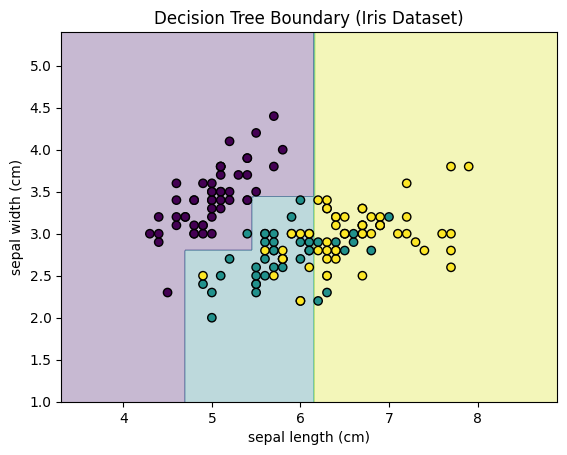

In [3]:
# Part C. Iris dataset: load, train decision tree, visualize (e.g. 2D boundary), report accuracy.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)



y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



X_vis = X[:, :2]

model_vis = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model_vis.fit(X_vis, y)



x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model_vis.predict(grid)
Z = Z.reshape(xx.shape)



plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])

plt.title("Decision Tree Boundary (Iris Dataset)")

plt.show()